In [1]:
!pip install pyspice
!pip install graphviz
import PySpice
print(PySpice.__version__)
!sudo apt-get update
!sudo apt-get install -y ngspice
!ngspice --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.5/158.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.6 MB/s eta 0:00:00
1.5
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main

In [8]:
# Import necessary libraries
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
from graphviz import Digraph
from IPython.display import Image, display
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Raw Ngspice Output:
 
No compatibility mode selected!


Circuit: Exercise 7

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 1
	Node                                  Voltage
	----                                  -------
	----	-------
	n2                               5.233083e+00
	n3                               3.000000e+00
	n1                               1.200000e+01

	Source	Current
	------	-------

	v1#branch                        -6.76692e-02
	v2#branch                        -1.73233e+00

 Resistor models (Simple linear resistor)
      model                     R

        rsh                     0
     narrow                     0
      short                     0
        tc1                     0
        tc2                     0
        tce                     0
       defw                 1e-05
          l                 1e-05
         kf                     0
         af                     0
          r                     0
     bv_max   

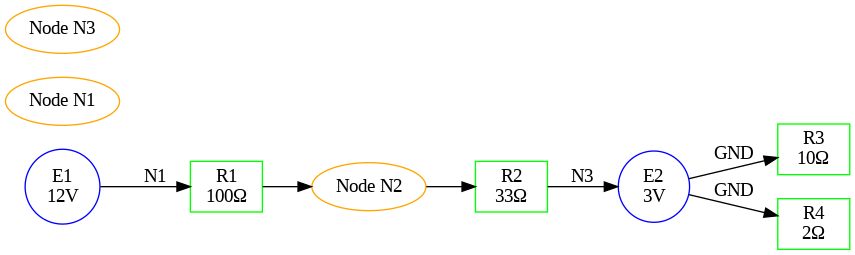

In [17]:
# Define the circuit
circuit = Circuit('Exercise 7')

# Add elements to the circuit
circuit.V(1, 'N1', circuit.gnd, 12@u_V)   # Voltage source E1 (12V)
circuit.V(2, 'N3', circuit.gnd, 3@u_V)    # Voltage source E2 (3V)
circuit.R(1, 'N1', 'N2', 100@u_Ohm)       # Resistor R1 (100 Ω)
circuit.R(2, 'N2', 'N3', 33@u_Ohm)        # Resistor R2 (33 Ω)
circuit.R(3, 'N3', circuit.gnd, 10@u_Ohm) # Resistor R3 (10 Ω)
circuit.R(4, 'N3', circuit.gnd, 2@u_Ohm)  # Resistor R4 (2 Ω)

# Manually add simulation commands to the netlist
netlist_content = f"""
.title Exercise 7
{circuit}
.op
.print op v(N1) v(N2) v(N3) i(V1) i(V2)
.end
"""

# Write the netlist to a file
netlist_file = 'exercise_7.cir'
with open(netlist_file, 'w') as f:
    f.write(netlist_content)

# Run Ngspice simulation
ngspice_output = subprocess.run(['ngspice', '-b', '-o', 'output.log', netlist_file], capture_output=True, text=True)

# Read Ngspice output from log file
with open('output.log', 'r') as f:
    ngspice_result = f.readlines()

# Display the raw Ngspice output for debugging
print("\nRaw Ngspice Output:\n", ''.join(ngspice_result))

# Parse Ngspice output for voltages and currents
data = []
for line in ngspice_result:
    if any(key in line.lower() for key in ["v(n1)", "v(n2)", "v(n3)", "i(v1)", "i(v2)"]):
        data.append(line.strip())

# Display the filtered data for debugging
print("\nFiltered Data:\n", data)

# Process the output to parse the relevant data
parsed_data = []

for line in data:
    items = line.split()
    if len(items) >= 2:
        try:
            # Try to convert the last item to float
            parsed_data.append([items[0], float(items[-1])])
        except ValueError:
            # Skip lines where conversion is not possible
            continue

# Create a DataFrame with parsed data
columns = ["Parameter", "Value"]
df = pd.DataFrame(parsed_data, columns=columns)

# Display the DataFrame
print("\nParsed DataFrame:\n", df)

# Visualize the circuit using Graphviz
dot = Digraph('Circuit', format='png')
dot.attr(rankdir='LR')  # Layout direction (Left to Right)

# Add nodes for components
dot.node('V1', 'E1\n12V', shape='circle', color='blue')  # Voltage source E1
dot.node('V2', 'E2\n3V', shape='circle', color='blue')   # Voltage source E2
dot.node('R1', 'R1\n100Ω', shape='rectangle', color='green')  # Resistor R1
dot.node('R2', 'R2\n33Ω', shape='rectangle', color='green')   # Resistor R2
dot.node('R3', 'R3\n10Ω', shape='rectangle', color='green')   # Resistor R3
dot.node('R4', 'R4\n2Ω', shape='rectangle', color='green')    # Resistor R4
dot.node('N1', 'Node N1', shape='ellipse', color='orange')    # Node N1
dot.node('N2', 'Node N2', shape='ellipse', color='orange')    # Node N2
dot.node('N3', 'Node N3', shape='ellipse', color='orange')    # Node N3

# Connect components
dot.edge('V1', 'R1', label='N1')  # Connect E1 to R1
dot.edge('R1', 'N2')              # Connect R1 to Node N2
dot.edge('N2', 'R2')              # Connect Node N2 to R2
dot.edge('R2', 'V2', label='N3')  # Connect R2 to E2
dot.edge('V2', 'R3', label='GND') # Connect E2 to R3
dot.edge('V2', 'R4', label='GND') # Connect E2 to R4

# Render the circuit diagram to a file and display it in Jupyter
dot.render('circuit_diagram', format='png', cleanup=True)
display(Image(filename='circuit_diagram.png'))



Node Voltages:
   Node  Voltage (V)
0   n2     5.233083
1   n3     3.000000
2   n1    12.000000

Branch Currents:
        Branch  Current (A)
0   v1#branch    -0.067669
1   v2#branch    -1.732330
2  resistance   100.000000

Power Dissipations:
 Empty DataFrame
Columns: [Resistor, Power (W)]
Index: []


<ipython-input-16-a2e3a1c375b8>:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Node", y="Voltage (V)", data=df_voltages, palette="viridis")


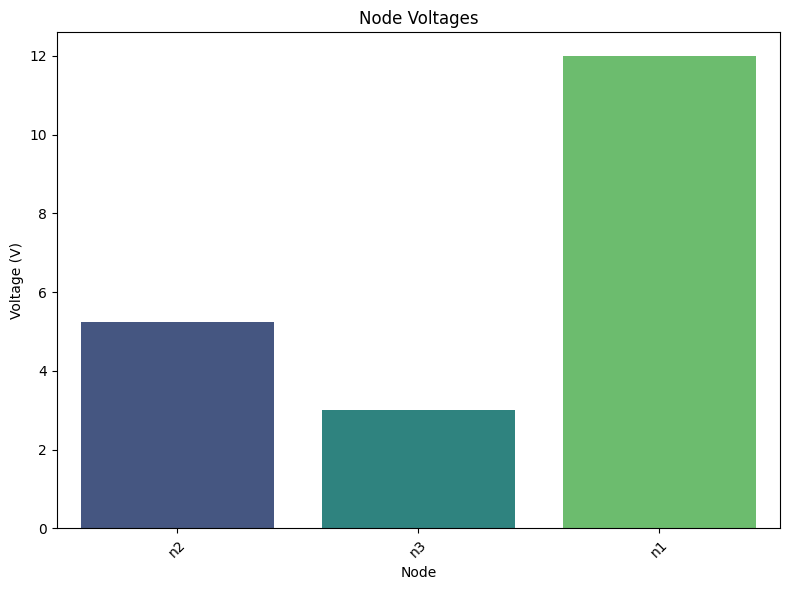

<ipython-input-16-a2e3a1c375b8>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Branch", y="Current (A)", data=df_currents, palette="viridis")


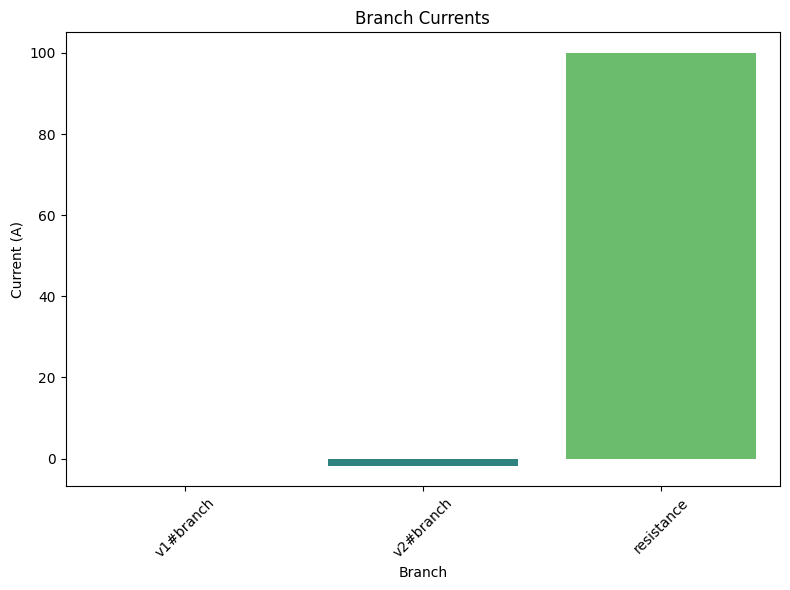

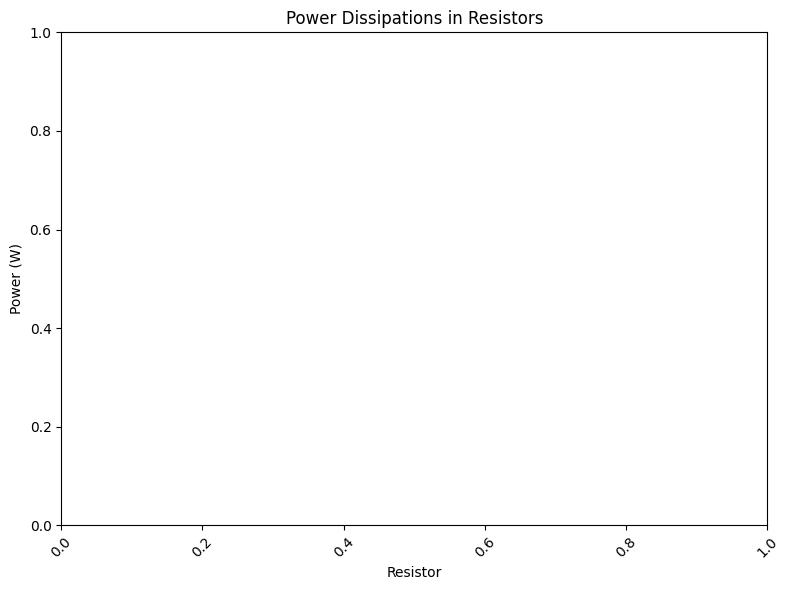

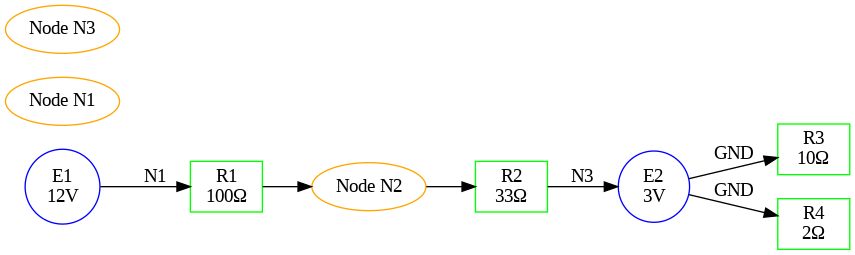

In [16]:
# Parse Ngspice output for voltages, currents, and power dissipation
voltages = {}
currents = {}
powers = {}

lines = ngspice_result.strip().split('\n')
for line in lines:
    line = line.strip()
    # Skip lines that are warnings, titles, or headers
    if line.startswith("Warning") or "No compatibility mode" in line or "Circuit:" in line:
        continue
    if line.startswith("Node") or line.startswith("Source") or line.startswith("Index"):
        continue
    if line.startswith("Resistor:") or line.startswith("Vsource:") or line.startswith("---"):
        continue
    if len(line.split()) < 2:
        continue

    items = line.split()
    # Check if the second item can be converted to a float
    try:
        float(items[1])
    except ValueError:
        continue

    if "n1" in items[0].lower() or "n2" in items[0].lower() or "n3" in items[0].lower():
        voltages[items[0]] = float(items[1])
    elif "v1#branch" in items[0].lower() or "v2#branch" in items[0].lower():
        currents[items[0]] = float(items[1])
    elif items[0].lower().startswith("r") and "i" in line:
        currents[items[0]] = float(items[1])
    elif items[0].lower().startswith("r") and "p" in line:
        powers[items[0]] = float(items[1])

# Create DataFrames for voltages, currents, and powers
df_voltages = pd.DataFrame(list(voltages.items()), columns=['Node', 'Voltage (V)'])
df_currents = pd.DataFrame(list(currents.items()), columns=['Branch', 'Current (A)'])
df_powers = pd.DataFrame(list(powers.items()), columns=['Resistor', 'Power (W)'])

# Display the DataFrames
print("\nNode Voltages:\n", df_voltages)
print("\nBranch Currents:\n", df_currents)
print("\nPower Dissipations:\n", df_powers)

# Plot Voltages
plt.figure(figsize=(8, 6))
sns.barplot(x="Node", y="Voltage (V)", data=df_voltages, palette="viridis")
plt.title("Node Voltages")
plt.xlabel("Node")
plt.ylabel("Voltage (V)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Currents
plt.figure(figsize=(8, 6))
sns.barplot(x="Branch", y="Current (A)", data=df_currents, palette="viridis")
plt.title("Branch Currents")
plt.xlabel("Branch")
plt.ylabel("Current (A)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Power Dissipations
plt.figure(figsize=(8, 6))
sns.barplot(x="Resistor", y="Power (W)", data=df_powers, palette="viridis")
plt.title("Power Dissipations in Resistors")
plt.xlabel("Resistor")
plt.ylabel("Power (W)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize the circuit using Graphviz
dot = Digraph('Circuit', format='png')
dot.attr(rankdir='LR')  # Layout direction (Left to Right)

# Add nodes for components
dot.node('V1', 'E1\n12V', shape='circle', color='blue')  # Voltage source E1
dot.node('V2', 'E2\n3V', shape='circle', color='blue')   # Voltage source E2
dot.node('R1', 'R1\n100Ω', shape='rectangle', color='green')  # Resistor R1
dot.node('R2', 'R2\n33Ω', shape='rectangle', color='green')   # Resistor R2
dot.node('R3', 'R3\n10Ω', shape='rectangle', color='green')   # Resistor R3
dot.node('R4', 'R4\n2Ω', shape='rectangle', color='green')    # Resistor R4
dot.node('N1', 'Node N1', shape='ellipse', color='orange')    # Node N1
dot.node('N2', 'Node N2', shape='ellipse', color='orange')    # Node N2
dot.node('N3', 'Node N3', shape='ellipse', color='orange')    # Node N3

# Connect components
dot.edge('V1', 'R1', label='N1')  # Connect E1 to R1
dot.edge('R1', 'N2')              # Connect R1 to Node N2
dot.edge('N2', 'R2')              # Connect Node N2 to R2
dot.edge('R2', 'V2', label='N3')  # Connect R2 to E2
dot.edge('V2', 'R3', label='GND') # Connect E2 to R3
dot.edge('V2', 'R4', label='GND') # Connect E2 to R4

# Render the circuit diagram to a
dot.render('circuit_diagram', format='png', cleanup=True)
display(Image(filename='circuit_diagram.png'))